In [2]:
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.utils import resample
import pandas as pd
import re
import numpy as np
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import wandb
import torch
import ast
import optuna
from tqdm import tqdm
import spacy
import seaborn as sns
from datasets import concatenate_datasets

### 1) Load parlBERT-vanilla model

In [3]:
parlbert = "chkla/parlbert-topic-german"
pipeline_classification_parlbert = pipeline("text-classification", model="chkla/parlbert-topic-german", device=0,
    truncation=True,
    max_length=512)

tokenizer = AutoTokenizer.from_pretrained(parlbert)
config = AutoConfig.from_pretrained(parlbert)

id2label = config.id2label
label2id = config.label2id
label_list = [label for idx, label in sorted(id2label.items())]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/354 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
predict_vanilla = pipeline("text-classification", model="chkla/parlbert-topic-german", return_all_scores=True)

Device set to use cpu
C:\Users\hanna\miniconda3\envs\im2024\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


### 2) Load and preprocess CAP dataset (skip and continue at 3) if cap_data.csv already exists)

In [ ]:
cap_df = pd.read_csv('../speech_1976-2021_v3.0.csv')

In [ ]:
# found duplicate speeches (with different labels!), problematic
dates_to_remove = ["2017-03-09", "2017-06-29", "2017-04-27"]

cap_df = cap_df[~cap_df["date"].isin(dates_to_remove)]

In [ ]:
cap_df

,lp,date,sentenceId,speaker,sentence,minorGer,minorInt
0,8,1976-12-16,1,Schmidt,Herr Praesident!,99,99
1,8,1976-12-16,2,Schmidt,Meine Damen und Herren!,99,99
2,8,1976-12-16,3,Schmidt,Der Regierungserklaerung soll ein Wort zum Ren...,1303,1303
3,8,1976-12-16,4,Schmidt,Kein Zweifel: Es hat zu einer ernsthaften Beun...,2011,2011
4,8,1976-12-16,5,Schmidt,Die Verhandlungsdelegationen beider Koalitions...,1300,1300
...,...,...,...,...,...,...,...
32291,19,2021-06-24,154,Merkel,"Meine Damen und Herren, hinter uns liegt ein M...",99,99
32292,19,2021-06-24,155,Merkel,"Ich bin ueberzeugt, dass wir nur zusammen als ...",331,331
32293,19,2021-06-24,156,Merkel,wie auch der anderen grossen Aufgaben meistern...,100,100
32294,19,2021-06-24,157,Merkel,Eine souveraene Europaeische Union sollte hier...,1910,1910


In [4]:
cap_df_complete = pd.read_csv('cap_data.csv')

In [5]:
cap_df.head()

NameError: name 'cap_df' is not defined

In [ ]:
# remove last two digits of the df to harmonize with parlbert, if 99, turn into 0, else strip the last two numbers

In [ ]:
cap_df['minorInt'] = np.where(cap_df['minorInt'] == 99, -1, cap_df['minorInt'] // 100)

In [ ]:
# then we need to map the labels from CAP (key) to match the labels of parlBERT (value)

In [ ]:
label_map = {
    1: 0,
    2: 1,
    3: 2,
    4: 3,
    5: 4,
    6: 5,
    7: 6,
    8: 7,
    9: 8,
    10: 9,
    12: 10,
    13: 11,
    14: 12,
    15: 13,
    16: 14,
    17: 15,
    18: 16,
    19: 17,
    20: 18,
    21: 19,
    23: 20,
}

In [ ]:
cap_df['mapped_label'] = cap_df['minorInt'].map(label_map).fillna(-1).astype(int)
cap_df["label_name"] = cap_df["mapped_label"].map(id2label).fillna("unlabeled")

In [ ]:
def replace_u_notation(text):
    '''Replace <U+XXXX> with the actual UNICODE character'''
    if not isinstance(text, str):
        return text
    def repl(match):
        codepoint = int(match.group(1), 16)
        return chr(codepoint)

    return re.sub(r'<U\+([0-9A-Fa-f]{4})>', repl, text)


def fix_control_chars(text):
    '''Replace UNICODE characters with actual character'''
    if not isinstance(text, str):
        return text

    replacements = {
        '\u0097': '—',
        '\u0093': '“',
        '\u0094': '”',
        '\u0092': '’',
        '\u0091': '‘',
        '\u0096': '–',
        '\u0084': '„',
    }

    def repl(match):
        codepoint = int(match.group(1), 16)
        char = chr(codepoint)
        return replacements.get(char, char)

    text = re.sub(r'<U\+([0-9A-Fa-f]{4})>', repl, text)

    for k, v in replacements.items():
        text = text.replace(k, v)
    return text


def normalize_quotes(text):
    '''Fix quotes'''
    if not isinstance(text, str):
        return text
    text = re.sub(r'""', '"', text)
    text = text.replace('"', '”')
    text = text.replace('„“', '„')  # fix accidental combination
    return text

cap_df["sentence"] = cap_df["sentence"].apply(replace_u_notation)
cap_df["sentence"] = cap_df["sentence"].apply(fix_control_chars)
cap_df["sentence"] = cap_df["sentence"].apply(normalize_quotes)
cap_df["sentence"] = cap_df["sentence"].str.replace("\uFEFF", "", regex=False)
cap_df["sentence"] = cap_df["sentence"].str.replace("\uFFFD", "—", regex=False)

In [ ]:
cap_df['mapped_label'] = cap_df['minorInt'].map(label_map).fillna(-1).astype(int)
cap_df["label_name"] = cap_df["mapped_label"].map(id2label).fillna("unlabeled")
cap_df_complete = cap_df.loc[cap_df['mapped_label'] != -1]

In [8]:
#!python -m spacy download de_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 MB 24.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
nlp = spacy.load("de_core_news_md", disable=["parser", "ner", "textcat"])

def lemmatize_sentence(sentence: str) -> str:
    doc = nlp(sentence)  # just one sentence
    tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(tokens)
tqdm.pandas(desc="Lemmatizing sentences")

cap_df_complete["sentence_lemmas"] = cap_df_complete["sentence"].progress_apply(lemmatize_sentence)

Lemmatizing sentences:  48%|████▊     | 12370/25995 [01:40<01:51, 122.73it/s]


KeyboardInterrupt: 

In [ ]:
n_prev = 2

def get_previous_sentences(df, col="sentence", n=2):
    prev_lists = []
    col_idx = df.columns.get_loc(col)
    date_idx = df.columns.get_loc("date")
    for i in range(len(df)):
        prev = []
        start_idx = max(0, i - n)
        for j in range(start_idx, i):
            if df.iloc[j, date_idx] == df.iloc[i, date_idx]:
                prev.append(df.iloc[j, col_idx])
        prev_lists.append(prev)
    return prev_lists

cap_df_complete["previous_sentences"] = get_previous_sentences(cap_df_complete, col="sentence", n=n_prev)
cap_df_complete["previous_sentences_lemmas"] = get_previous_sentences(cap_df_complete, col="sentence_lemmas", n=n_prev)

In [ ]:
def make_svm_text(row, lemmas=False):
    if lemmas:
        prev = row["previous_sentences_lemmas"]
        current = row["sentence_lemmas"]
    else:
        prev = row["previous_sentences"]
        current = row["sentence"]
    return prev + [current]

cap_df_complete["svm_text"] = cap_df_complete.apply(make_svm_text, axis=1, args=(False,))

cap_df_complete["svm_text_lemmas"] = cap_df_complete.apply(make_svm_text, axis=1, args=(True,))

In [ ]:
cap_df['label_name'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Mapped Labels")
plt.xticks(rotation=60, ha='right')
plt.show()
#plt.savefig('label_distribution.png',bbox_inches="tight")

In [ ]:
# Counts per class
counts = cap_df['label_name'].value_counts()

# Mean number of instances per class
mean_count = counts.mean()
print("Mean instances per class:", mean_count)
# -> why i chose 2000 for balanced dataset

In [ ]:
print(counts)

label_name
International     7987
unlabeled         5086
Macroeconomics    4347
Government        1922
Defense           1565
Labor             1409
Civil             1138
Domestic          1031
Energy             938
Social             919
Foreign            831
Health             707
Law                645
Environment        593
Technology         490
Immigration        483
Education          426
Transportation     187
Housing            170
Agriculture        110
Culture             79
Public              18
Name: count, dtype: int64


In [ ]:
# remove -1

In [ ]:
cap_df_complete.head()

In [ ]:
cap_df_complete.to_csv("../cap_data.csv", encoding="utf-8", index=False)

In [ ]:
# now we can fine-tune and test the model

### 3) Preprocessing

In [11]:
cap_df_complete = pd.read_csv('../cap_data.csv')

In [12]:
# context split
docs = cap_df_complete[["date"]].drop_duplicates()
train_docs, temp_docs = train_test_split(docs, test_size=0.3, random_state=42)
dev_docs, test_docs   = train_test_split(temp_docs, test_size=0.5, random_state=42)

cap_df_complete['svm_text'] = cap_df_complete['svm_text'].apply(ast.literal_eval)
cap_df_complete['svm_text_lemmas'] = cap_df_complete['svm_text_lemmas'].apply(ast.literal_eval)

train_df = cap_df_complete.merge(train_docs, on=["date"])
dev_df   = cap_df_complete.merge(dev_docs, on=["date"])
test_df  = cap_df_complete.merge(test_docs, on=["date"])

train_texts = train_df["svm_text"].tolist()
dev_texts   = dev_df["svm_text"].tolist()
test_texts  = test_df["svm_text"].tolist()

train_texts_lemmas = train_df["svm_text_lemmas"].tolist()
dev_texts_lemmas   = dev_df["svm_text_lemmas"].tolist()
test_texts_lemmas  = test_df["svm_text_lemmas"].tolist()

train_labels = train_df["mapped_label"].tolist()
dev_labels   = dev_df["mapped_label"].tolist()
test_labels  = test_df["mapped_label"].tolist()

In [13]:
print(f"Amount of train samples: {len(train_df)}")
print(f"Amount of dev samples: {len(dev_df)}")
print(f"Amount of test samples: {len(test_df)}")

Amount of train samples: 17521
Amount of dev samples: 4397
Amount of test samples: 4077


## Create balanced data versions

In [ ]:
def balance_dataset(texts, labels, max_samples=2000, random_state=42):
    """
    Balances a dataset by downsampling each class to a maximum number of samples (default: 2k per class).

    Parameters:
        texts (list): List of text samples.
        labels (list): Corresponding list of labels.
        max_samples (int): Maximum number of samples per class.
        random_state (int): Random state for reproducibility.

    Returns:
        balanced_texts (list): List of balanced text samples.
        balanced_labels (list): List of balanced labels.
    """
    df = pd.DataFrame({
        "text": texts,
        "label": labels
    })

    balanced_dfs = []

    for cls, group in df.groupby("label"):
        if len(group) > max_samples:
            group_downsampled = resample(
                group,
                replace=False,
                n_samples=max_samples,
                random_state=random_state
            )
            balanced_dfs.append(group_downsampled)
        else:
            balanced_dfs.append(group)

    df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=random_state)

    balanced_texts = df_balanced["text"].tolist()
    balanced_labels = df_balanced["label"].tolist()

    return balanced_texts, balanced_labels

In [14]:
# train
texts_balanced, labels_balanced = balance_dataset(
    train_texts,
    train_labels,
    max_samples=2000
)

# train (lemmatized)
texts_balanced_lemmas, labels_balanced_lemmas = balance_dataset(
    train_texts_lemmas,
    train_labels,
    max_samples=2000
)

# train + dev
texts_final_train  = train_texts + dev_texts
labels_final_train = train_labels + dev_labels

texts_balanced_final, labels_balanced_final = balance_dataset(
    texts_final_train,
    labels_final_train,
    max_samples=2000
)

# train + dev (lemmatized)
texts_final_train_lemmas  = train_texts_lemmas + dev_texts_lemmas
labels_final_train = train_labels + dev_labels

texts_balanced_final_lemmas, labels_balanced_final_lemmas = balance_dataset(
    texts_final_train_lemmas,
    labels_final_train,
    max_samples=2000
)

## Generate vanilla parlBERT predictions

### Obtain labels (can skip if parlbert_test.csv already exists)

In [ ]:
train_texts_v_pb = train_df["sentence"].tolist()
dev_texts_v_pb   = dev_df["sentence"].tolist()
test_texts_v_pb  = test_df["sentence"].tolist()

In [ ]:
# merge together again for vanilla parlBERT
train_df_pb = pd.DataFrame({"sentence": train_texts_v_pb, "mapped_label": train_labels})
train_df_pb["split"] = "train"

dev_df_pb = pd.DataFrame({"sentence": dev_texts_v_pb, "mapped_label": dev_labels})
dev_df_pb["split"] = "dev"

test_df_pb = pd.DataFrame({"sentence": test_texts_v_pb, "mapped_label": test_labels})
test_df_pb["split"] = "test"

# Unlabeled (-1)
# unlabeled_df = cap_df.loc[cap_df["mapped_label"] == -1].copy()
# unlabeled_df["split"] = "unlabeled"


# Concatenate all
#final_df = pd.concat([train_df, dev_df, test_df, unlabeled_df], ignore_index=True)
final_df = pd.concat([train_df_pb, dev_df_pb, test_df_pb], ignore_index=True)
final_df["label_name"] = final_df["mapped_label"].map(id2label).fillna("unlabeled")

final_df = final_df[["sentence", "mapped_label", "label_name", "split"]]

# full mask for unlabeled + test + dev
#mask = final_df["split"].isin(["unlabeled", "test", "dev"])
mask = final_df["split"].isin(["test", "dev"])
subset = final_df.loc[mask, "sentence"].tolist()
subset_idx = final_df.index[mask]

all_labels = []
all_scores = []
all_probs = []

for sentence in tqdm.tqdm(subset):
    results = predict_vanilla(sentence)

    # unwrap if necessary
    if isinstance(results[0], list):
        results = results[0]

    # top label & score
    top_label = max(results, key=lambda x: x["score"])["label"]
    top_score = max(results, key=lambda x: x["score"])["score"]
    #print(f"Results: {results}, top_label: {top_label}, top_score: {top_score}")

    # append
    all_labels.append(top_label)
    all_scores.append(top_score)
    all_probs.append(results)

# assign back safely for all
final_df["parlbert_label"] = None
final_df["parlbert_score"] = None
final_df["parlbert_probs"] = None

for i, idx in enumerate(subset_idx):
    final_df.at[idx, "parlbert_label"] = all_labels[i]
    final_df.at[idx, "parlbert_score"] = all_scores[i]
    final_df.at[idx, "parlbert_probs"] = all_probs[i]

final_df.to_csv("parlbert_test.csv", index=False)

100%|██████████████████████████████████████████████████████████████████████████████| 8474/8474 [24:06<00:00,  5.86it/s]


In [ ]:
train_df

,lp,date,sentenceId,speaker,sentence,minorGer,minorInt,mapped_label,label_name,sentence_lemmas,previous_sentences,previous_sentences_lemmas,svm_text,svm_text_lemmas
0,8,1977-06-17,6,Schmidt,Einen anderen Grund fuer dieses nicht einfache...,200,2,1,Civil,ein anderer Grund fuer dieser nicht einfach Ve...,[],[],[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...
1,8,1977-06-17,7,Schmidt,Wir feiern ihn und muessen zugleich doch insta...,200,2,1,Civil,wir feiern ihn und muessen zugleich doch Insta...,['Einen anderen Grund fuer dieses nicht einfac...,['ein anderer Grund fuer dieser nicht einfach ...,[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...
2,8,1977-06-17,8,Schmidt,"Ich denke, dem Sinne des Feiertages kommt wohl...",200,2,1,Civil,ich denken der Sinn der Feiertag kommen wohl d...,['Einen anderen Grund fuer dieses nicht einfac...,['ein anderer Grund fuer dieser nicht einfach ...,[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...
3,8,1977-06-17,10,Schmidt,Schon einen Tag nach den Ereignissen schrieb v...,200,2,1,Civil,schon ein Tag nach der Ereignis schreiben vor ...,['Wir feiern ihn und muessen zugleich doch ins...,['wir feiern ihn und muessen zugleich doch Ins...,[Wir feiern ihn und muessen zugleich doch inst...,[wir feiern ihn und muessen zugleich doch Inst...
4,8,1977-06-17,11,Schmidt,"Die freiheitlich-demokratische Linie, ja freih...",200,2,1,Civil,der freiheitlich-demokratisch Linie ja freihei...,"['Ich denke, dem Sinne des Feiertages kommt wo...",['ich denken der Sinn der Feiertag kommen wohl...,"[Ich denke, dem Sinne des Feiertages kommt woh...",[ich denken der Sinn der Feiertag kommen wohl ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17516,19,2021-06-24,152,Merkel,Immer mehr Mitgliedstaaten in der NATO erreich...,1602,16,14,Defense,immer mehr Mitgliedstaat in der NATO erreichen...,['Daher wird Deutschland weiter seinen Beitrag...,['daher werden Deutschland weiter sein Beitrag...,[Daher wird Deutschland weiter seinen Beitrag ...,[daher werden Deutschland weiter sein Beitrag ...
17517,19,2021-06-24,153,Merkel,Deutschland wird hierbei in den naechsten Jahr...,1600,16,14,Defense,Deutschland werden hierbei in der naechster Ja...,"['Und deswegen bleibt es auch notwendig, dass ...",['und deswegen bleiben es auch notwendig dass ...,"[Und deswegen bleibt es auch notwendig, dass w...",[und deswegen bleiben es auch notwendig dass w...
17518,19,2021-06-24,155,Merkel,"Ich bin ueberzeugt, dass wir nur zusammen als ...",331,3,2,Health,ich sein ueberzeugt dass wir nur zusammen als ...,['Immer mehr Mitgliedstaaten in der NATO errei...,['immer mehr Mitgliedstaat in der NATO erreich...,[Immer mehr Mitgliedstaaten in der NATO erreic...,[immer mehr Mitgliedstaat in der NATO erreiche...
17519,19,2021-06-24,156,Merkel,wie auch der anderen grossen Aufgaben meistern...,100,1,0,Macroeconomics,wie auch der anderer gross Aufgabe meistern ko...,['Deutschland wird hierbei in den naechsten Ja...,['Deutschland werden hierbei in der naechster ...,[Deutschland wird hierbei in den naechsten Jah...,[Deutschland werden hierbei in der naechster J...


In [ ]:
train_df["sentence_context"] = train_df["svm_text"].apply(lambda x: " ".join(x))
dev_df["sentence_context"] = dev_df["svm_text"].apply(lambda x: " ".join(x))
test_df["sentence_context"] = test_df["svm_text"].apply(lambda x: " ".join(x))
train_texts_v_pb = train_df["sentence_context"].tolist()
dev_texts_v_pb   = dev_df["sentence_context"].tolist()
test_texts_v_pb  = test_df["sentence_context"].tolist()

In [ ]:
# merge together again for vanilla parlBERT
train_df_pb = pd.DataFrame({"sentence": train_texts_v_pb, "mapped_label": train_labels})
train_df_pb["split"] = "train"

dev_df_pb = pd.DataFrame({"sentence": dev_texts_v_pb, "mapped_label": dev_labels})
dev_df_pb["split"] = "dev"

test_df_pb = pd.DataFrame({"sentence": test_texts_v_pb, "mapped_label": test_labels})
test_df_pb["split"] = "test"

# Unlabeled (-1)
#unlabeled_df = cap_df.loc[cap_df["mapped_label"] == -1].copy()
#unlabeled_df["split"] = "unlabeled"


# Concatenate all
#final_df = pd.concat([train_df, dev_df, test_df, unlabeled_df], ignore_index=True)
final_df = pd.concat([train_df_pb, dev_df_pb, test_df_pb], ignore_index=True)
final_df["label_name"] = final_df["mapped_label"].map(id2label).fillna("unlabeled")

final_df = final_df[["sentence", "mapped_label", "label_name", "split"]]

# full mask for unlabeled + test + dev
#mask = final_df["split"].isin(["unlabeled", "test", "dev"])
mask = final_df["split"].isin(["test", "dev"])
subset = final_df.loc[mask, "sentence"].tolist()
subset_idx = final_df.index[mask]

all_labels = []
all_scores = []
all_probs = []

for sentence in tqdm.tqdm(subset):
    results = predict_vanilla(sentence)

    # unwrap if necessary
    if isinstance(results[0], list):
        results = results[0]

    # top label & score
    top_label = max(results, key=lambda x: x["score"])["label"]
    top_score = max(results, key=lambda x: x["score"])["score"]
    #print(f"Results: {results}, top_label: {top_label}, top_score: {top_score}")

    # append
    all_labels.append(top_label)
    all_scores.append(top_score)
    all_probs.append(results)

# assign back safely for all
final_df["parlbert_label"] = None
final_df["parlbert_score"] = None
final_df["parlbert_probs"] = None

for i, idx in enumerate(subset_idx):
    final_df.at[idx, "parlbert_label"] = all_labels[i]
    final_df.at[idx, "parlbert_score"] = all_scores[i]
    final_df.at[idx, "parlbert_probs"] = all_probs[i]

final_df.to_csv("parlbert_test_context.csv", index=False)

100%|████████████████████████████████████████████████████████████████████████████| 8474/8474 [1:02:52<00:00,  2.25it/s]


In [ ]:
train_df["sentence_context"] = train_df["svm_text"].apply(
    lambda x: " ".join(x[-2:]) if isinstance(x, list) else str(x)
)
dev_df["sentence_context"] = dev_df["svm_text"].apply(
    lambda x: " ".join(x[-2:]) if isinstance(x, list) else str(x)
)
test_df["sentence_context"] = test_df["svm_text"].apply(
    lambda x: " ".join(x[-2:]) if isinstance(x, list) else str(x)
)
train_texts_v_pb = train_df["sentence_context"].tolist()
dev_texts_v_pb   = dev_df["sentence_context"].tolist()
test_texts_v_pb  = test_df["sentence_context"].tolist()

In [ ]:
train_df

,lp,date,sentenceId,speaker,sentence,minorGer,minorInt,mapped_label,label_name,sentence_lemmas,previous_sentences,previous_sentences_lemmas,svm_text,svm_text_lemmas,sentence_context
0,8,1977-06-17,6,Schmidt,Einen anderen Grund fuer dieses nicht einfache...,200,2,1,Civil,ein anderer Grund fuer dieser nicht einfach Ve...,[],[],[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...,Einen anderen Grund fuer dieses nicht einfache...
1,8,1977-06-17,7,Schmidt,Wir feiern ihn und muessen zugleich doch insta...,200,2,1,Civil,wir feiern ihn und muessen zugleich doch Insta...,['Einen anderen Grund fuer dieses nicht einfac...,['ein anderer Grund fuer dieser nicht einfach ...,[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...,Einen anderen Grund fuer dieses nicht einfache...
2,8,1977-06-17,8,Schmidt,"Ich denke, dem Sinne des Feiertages kommt wohl...",200,2,1,Civil,ich denken der Sinn der Feiertag kommen wohl d...,['Einen anderen Grund fuer dieses nicht einfac...,['ein anderer Grund fuer dieser nicht einfach ...,[Einen anderen Grund fuer dieses nicht einfach...,[ein anderer Grund fuer dieser nicht einfach V...,Wir feiern ihn und muessen zugleich doch insta...
3,8,1977-06-17,10,Schmidt,Schon einen Tag nach den Ereignissen schrieb v...,200,2,1,Civil,schon ein Tag nach der Ereignis schreiben vor ...,['Wir feiern ihn und muessen zugleich doch ins...,['wir feiern ihn und muessen zugleich doch Ins...,[Wir feiern ihn und muessen zugleich doch inst...,[wir feiern ihn und muessen zugleich doch Inst...,"Ich denke, dem Sinne des Feiertages kommt wohl..."
4,8,1977-06-17,11,Schmidt,"Die freiheitlich-demokratische Linie, ja freih...",200,2,1,Civil,der freiheitlich-demokratisch Linie ja freihei...,"['Ich denke, dem Sinne des Feiertages kommt wo...",['ich denken der Sinn der Feiertag kommen wohl...,"[Ich denke, dem Sinne des Feiertages kommt woh...",[ich denken der Sinn der Feiertag kommen wohl ...,Schon einen Tag nach den Ereignissen schrieb v...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17516,19,2021-06-24,152,Merkel,Immer mehr Mitgliedstaaten in der NATO erreich...,1602,16,14,Defense,immer mehr Mitgliedstaat in der NATO erreichen...,['Daher wird Deutschland weiter seinen Beitrag...,['daher werden Deutschland weiter sein Beitrag...,[Daher wird Deutschland weiter seinen Beitrag ...,[daher werden Deutschland weiter sein Beitrag ...,"Und deswegen bleibt es auch notwendig, dass wi..."
17517,19,2021-06-24,153,Merkel,Deutschland wird hierbei in den naechsten Jahr...,1600,16,14,Defense,Deutschland werden hierbei in der naechster Ja...,"['Und deswegen bleibt es auch notwendig, dass ...",['und deswegen bleiben es auch notwendig dass ...,"[Und deswegen bleibt es auch notwendig, dass w...",[und deswegen bleiben es auch notwendig dass w...,Immer mehr Mitgliedstaaten in der NATO erreich...
17518,19,2021-06-24,155,Merkel,"Ich bin ueberzeugt, dass wir nur zusammen als ...",331,3,2,Health,ich sein ueberzeugt dass wir nur zusammen als ...,['Immer mehr Mitgliedstaaten in der NATO errei...,['immer mehr Mitgliedstaat in der NATO erreich...,[Immer mehr Mitgliedstaaten in der NATO erreic...,[immer mehr Mitgliedstaat in der NATO erreiche...,Deutschland wird hierbei in den naechsten Jahr...
17519,19,2021-06-24,156,Merkel,wie auch der anderen grossen Aufgaben meistern...,100,1,0,Macroeconomics,wie auch der anderer gross Aufgabe meistern ko...,['Deutschland wird hierbei in den naechsten Ja...,['Deutschland werden hierbei in der naechster ...,[Deutschland wird hierbei in den naechsten Jah...,[Deutschland werden hierbei in der naechster J...,"Ich bin ueberzeugt, dass wir nur zusammen als ..."


In [ ]:
# merge together again for vanilla parlBERT
train_df_pb = pd.DataFrame({"sentence": train_texts_v_pb, "mapped_label": train_labels})
train_df_pb["split"] = "train"

dev_df_pb = pd.DataFrame({"sentence": dev_texts_v_pb, "mapped_label": dev_labels})
dev_df_pb["split"] = "dev"

test_df_pb = pd.DataFrame({"sentence": test_texts_v_pb, "mapped_label": test_labels})
test_df_pb["split"] = "test"

# Unlabeled (-1)
#unlabeled_df = cap_df.loc[cap_df["mapped_label"] == -1].copy()
#unlabeled_df["split"] = "unlabeled"


# Concatenate all
#final_df = pd.concat([train_df, dev_df, test_df, unlabeled_df], ignore_index=True)
final_df = pd.concat([train_df_pb, dev_df_pb, test_df_pb], ignore_index=True)
final_df["label_name"] = final_df["mapped_label"].map(id2label).fillna("unlabeled")

final_df = final_df[["sentence", "mapped_label", "label_name", "split"]]

# full mask for unlabeled + test + dev
#mask = final_df["split"].isin(["unlabeled", "test", "dev"])
mask = final_df["split"].isin(["test", "dev"])
subset = final_df.loc[mask, "sentence"].tolist()
subset_idx = final_df.index[mask]

all_labels = []
all_scores = []
all_probs = []

for sentence in tqdm.tqdm(subset):
    results = predict_vanilla(sentence)

    # unwrap if necessary
    if isinstance(results[0], list):
        results = results[0]

    # top label & score
    top_label = max(results, key=lambda x: x["score"])["label"]
    top_score = max(results, key=lambda x: x["score"])["score"]
    #print(f"Results: {results}, top_label: {top_label}, top_score: {top_score}")

    # append
    all_labels.append(top_label)
    all_scores.append(top_score)
    all_probs.append(results)

# assign back safely for all
final_df["parlbert_label"] = None
final_df["parlbert_score"] = None
final_df["parlbert_probs"] = None

for i, idx in enumerate(subset_idx):
    final_df.at[idx, "parlbert_label"] = all_labels[i]
    final_df.at[idx, "parlbert_score"] = all_scores[i]
    final_df.at[idx, "parlbert_probs"] = all_probs[i]

final_df.to_csv("parlbert_test_context_1.csv", index=False)

100%|██████████████████████████████████████████████████████████████████████████████| 8474/8474 [38:57<00:00,  3.62it/s]


In [ ]:
final_df

# Fine-tuning parlBERT

### Preprocessing

In [17]:
print(f"Amount of train samples: {len(train_texts)}")
print(f"Amount of dev samples: {len(dev_texts)}")
print(f"Amount of test samples: {len(test_texts)}")
print(f"Amount of train samples (balanced): {len(texts_balanced)}")
print(f"Amount of train samples (balanced, final): {len(texts_balanced_final)}")

Amount of train samples: 17521
Amount of dev samples: 4397
Amount of test samples: 4077
Amount of train samples (balanced): 13132
Amount of train samples (balanced, final): 15635


In [39]:
def tokenize_with_context_segment_ids(svm_texts, tokenizer, num_context=2, max_length=256):
    """
    svm_texts: list of lists, each inner list contains sentences in order
               [oldest_prev, ..., most_recent_prev, target_sentence]
    num_context: number of previous sentences to include (0,1,2)
    Returns: dictionary with input_ids, attention_mask, token_type_ids
    """
    input_ids_list = []
    attention_mask_list = []
    token_type_ids_list = []

    for text_list in svm_texts:
        target = text_list[-1]
        context_sentences = text_list[-(num_context+1):-1] if num_context > 0 else []

        # Reverse context: keep most recent context closest to target
        context_sentences = context_sentences[::-1]

        # Place target at the end
        all_sentences = context_sentences + [target]
        input_text = " [SEP] ".join([str(s) for s in all_sentences])

        enc = tokenizer.encode_plus(
            input_text,
            add_special_tokens=True,
            max_length=max_length,
            truncation='only_first',  # if truncation needed, from beginning (since target is at the end)
            padding='max_length'
        )

        input_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"]

        #  token_type_ids: 0 for context, 1 for target
        token_type_ids = []
        tokens_accum = 0
        for idx, sentence in enumerate(all_sentences):
            sentence_tokens = tokenizer.tokenize(sentence)
            length = len(sentence_tokens)
            segment_id = 1 if idx == len(all_sentences) - 1 else 0
            token_type_ids.extend([segment_id] * length)
            token_type_ids.append(segment_id)  # for [SEP]
            tokens_accum += length + 1

        # Add [CLS] at the start
        token_type_ids = [0] + token_type_ids

        # Pad/truncate token_type_ids to max_length
        if len(token_type_ids) < max_length:
            pad_len = max_length - len(token_type_ids)
            token_type_ids += [0] * pad_len
        else:
            token_type_ids = token_type_ids[:max_length]

        if len(input_ids) < max_length:
            pad_len = max_length - len(input_ids)
            input_ids += [tokenizer.pad_token_id] * pad_len
            attention_mask += [0] * pad_len
        else:
            input_ids = input_ids[:max_length]
            attention_mask = attention_mask[:max_length]

        input_ids_list.append(input_ids)
        attention_mask_list.append(attention_mask)
        token_type_ids_list.append(token_type_ids)

    return {
        "input_ids": torch.tensor(input_ids_list),
        "attention_mask": torch.tensor(attention_mask_list),
        "token_type_ids": torch.tensor(token_type_ids_list)
    }

In [19]:
def compute_metrics(eval_pred):
    """
    eval_pred: (logits, labels)
    - logits: raw model outputs (before softmax)
    - labels: true class labels
    """
    logits, labels = eval_pred
    probs = np.exp(logits) / np.exp(logits).sum(-1, keepdims=True)  # softmax
    preds = probs.argmax(axis=-1)

    f1_macro = f1_score(labels, preds, average="macro")
    try:
        auc_macro = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        auc_macro = float("nan")

    return {
        "f1_macro": f1_macro,
        "auc_macro": auc_macro,
        "accuracy": accuracy_score(labels, preds),
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

In [20]:
def model_init():
    '''initialize model for hyperparameter search'''
    return AutoModelForSequenceClassification.from_pretrained(
        parlbert,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id
    )

In [24]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=100)

In [25]:
training_args = TrainingArguments(
    output_dir="./results",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    metric_for_best_model="f1_macro",
    load_best_model_at_end=True,
)

In [36]:
class WeightedTrainer(Trainer):
    '''use class weights with cross-entropy loss (rare classes get higher weight, common classes lower weight.)'''
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Move weights to same device as logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
def objective(trial, train_texts, train_labels, dev_texts, dev_labels, tokenizer, training_args, model_init, compute_metrics, texts_balanced=None, max_length=256):

    # --- Hyperparameters ---
    learning_rate = trial.suggest_float("learning_rate", 2e-5, 4e-5, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 3, 4)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.07)
    num_context = trial.suggest_int("num_context", 0, 2)
    used_texts = texts_balanced
    used_labels = labels_balanced

    # --- Pre-tokenize with function ---
    train_encodings = tokenize_with_context_segment_ids(used_texts, tokenizer=tokenizer, num_context=num_context, max_length=max_length)
    dev_encodings = tokenize_with_context_segment_ids(dev_texts, tokenizer=tokenizer, num_context=num_context, max_length=max_length)

    train_dataset = Dataset.from_dict({
        "input_ids": train_encodings["input_ids"],
        "attention_mask": train_encodings["attention_mask"],
        "token_type_ids": train_encodings["token_type_ids"],
        "labels": torch.tensor(used_labels)
    })

    dev_dataset = Dataset.from_dict({
        "input_ids": dev_encodings["input_ids"],
        "attention_mask": dev_encodings["attention_mask"],
        "token_type_ids": dev_encodings["token_type_ids"],
        "labels": torch.tensor(dev_labels)
    })

    # --- Class weights (based on train set) ---
    class_counts = np.bincount(used_labels)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float)

    # --- Trainer ---
    trainer = WeightedTrainer(
        class_weights=class_weights,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=dev_dataset,
        tokenizer=tokenizer,
        model_init=model_init,
        compute_metrics=compute_metrics
    )

    trainer.args.learning_rate = learning_rate
    trainer.args.num_train_epochs = num_train_epochs
    trainer.args.per_device_train_batch_size = per_device_train_batch_size
    trainer.args.weight_decay = weight_decay

    # --- train + evaluate  ---
    trainer.train()
    metrics = trainer.evaluate()
    return metrics["eval_f1_macro"]

In [ ]:
study = optuna.create_study(direction="maximize", pruner=pruner)
study.optimize(
    lambda trial: objective(
        trial,
        train_texts=train_texts,
        train_labels=train_labels,
        dev_texts=dev_texts,
        dev_labels=dev_labels,
        tokenizer=tokenizer,
        training_args=training_args,
        model_init=model_init,
        compute_metrics=compute_metrics,
        texts_balanced=texts_balanced
    ),
    n_trials=2
)

[I 2025-09-17 07:58:06,439] A new study created in memory with name: no-name-42710c94-0453-43b3-8ba0-16b4c0999e22
/tmp/ipython-input-3592999002.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hannahsteinbach (witcrafts) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,F1 Macro,Auc Macro,Accuracy,F1 Micro,F1 Weighted
1,0.884000,0.865602,0.688985,0.970286,0.721174,0.721174,0.722757
2,0.460300,0.945813,0.711707,0.972681,0.740277,0.740277,0.743537
3,0.212400,1.088515,0.718455,0.971256,0.751649,0.751649,0.753521


[I 2025-09-17 08:33:53,347] Trial 0 finished with value: 0.7184552758830001 and parameters: {'learning_rate': 2.672669365772627e-05, 'num_train_epochs': 3, 'per_device_train_batch_size': 8, 'weight_decay': 0.014810009452270324, 'num_context': 2}. Best is trial 0 with value: 0.7184552758830001.
/tmp/ipython-input-3592999002.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Epoch,Training Loss,Validation Loss,F1 Macro,Auc Macro,Accuracy,F1 Micro,F1 Weighted
1,No log,0.932338,0.662919,0.967405,0.699340,0.699340,0.701698
2,1.038900,0.930696,0.680368,0.971359,0.700478,0.700478,0.704186
3,0.486700,0.970385,0.682561,0.970315,0.717535,0.717535,0.719311
4,0.273000,0.972916,0.693593,0.970312,0.724812,0.724812,0.727306


[I 2025-09-17 09:17:39,969] Trial 1 finished with value: 0.6935930107469511 and parameters: {'learning_rate': 2.5639728044034066e-05, 'num_train_epochs': 4, 'per_device_train_batch_size': 32, 'weight_decay': 0.060087175437801114, 'num_context': 1}. Best is trial 0 with value: 0.7184552758830001.


In [ ]:
print("Best trial:")
best_trial = study.best_trial

print(f"  Value (F1 macro): {best_trial.value}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial:
  Value (F1 macro): 0.7184552758830001
  Params:
    learning_rate: 2.672669365772627e-05
    num_train_epochs: 3
    per_device_train_batch_size: 8
    weight_decay: 0.014810009452270324
    num_context: 2


# Train on train + dev and evaluate on test set

In [26]:
train_dev_texts = train_texts + dev_texts
train_dev_labels = train_labels + dev_labels

In [ ]:
best_num_context=2

# --- Compute class weights from balanced labels ---
class_counts = np.bincount(labels_balanced_final)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# --- Create dataset ---
train_encodings = tokenize_with_context_segment_ids(
    texts_balanced_final,
    tokenizer=tokenizer,
    num_context=best_num_context,
    max_length=256
)

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "token_type_ids": train_encodings["token_type_ids"],
    "labels": torch.tensor(labels_balanced_final)
})

# --- Initialize model ---
model = AutoModelForSequenceClassification.from_pretrained(
    parlbert,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# --- Training arguments ---
training_args = TrainingArguments(
    output_dir="./results_final",
    save_strategy="epoch",
    learning_rate=2.672669365772627e-05,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.014810009452270324,
)

# --- Use WeightedTrainer ---
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

trainer.train()


/tmp/ipython-input-3592999002.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hannahsteinbach (witcrafts) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,1.345300
1000,0.997700
1500,0.900900
2000,0.793500
2500,0.458100
3000,0.476300
3500,0.455100
4000,0.409900
4500,0.194400
5000,0.235100


TrainOutput(global_step=5865, training_loss=0.5684750894349757, metrics={'train_runtime': 2159.0865, 'train_samples_per_second': 21.724, 'train_steps_per_second': 2.716, 'total_flos': 6171664691105280.0, 'train_loss': 0.5684750894349757, 'epoch': 3.0})

In [ ]:
test_encodings = tokenize_with_context_segment_ids(
    test_texts,
    tokenizer=tokenizer,
    num_context=best_num_context,
    max_length=256
)

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "token_type_ids": test_encodings["token_type_ids"],
    "labels": torch.tensor(test_labels)
})

In [ ]:
trainer.evaluate(test_dataset)

{'eval_loss': 1.0089646577835083,
 'eval_f1_macro': 0.7045308901850793,
 'eval_auc_macro': 0.9702147826571975,
 'eval_accuracy': 0.7640421878832475,
 'eval_f1_micro': 0.7640421878832475,
 'eval_f1_weighted': 0.7659372758555913,
 'eval_runtime': 61.6493,
 'eval_samples_per_second': 66.132,
 'eval_steps_per_second': 8.273,
 'epoch': 3.0}

In [ ]:
preds = trainer.predict(test_dataset)
logits = preds.predictions
pred_labels = logits.argmax(axis=1)
#pred_labels = [id2label[i] for i in pred_indices]

In [ ]:
f1_macro = f1_score(test_labels, pred_labels, average='macro')
f1_micro = f1_score(test_labels, pred_labels, average='micro')
f1_weighted= f1_score(test_labels, pred_labels, average='weighted')

print("F1-Macro on test set:", f1_macro)
print("F1-Micro on test set:", f1_micro)
print("F1 weighted:", f1_weighted)

print(classification_report(
    [id2label[i] for i in test_labels],
    [id2label[i] for i in pred_labels]
))

F1-Macro on test set: 0.7045308901850793
F1-Micro on test set: 0.7640421878832475
F1 weighted: 0.7659372758555913
                precision    recall  f1-score   support

   Agriculture       0.50      1.00      0.67         3
         Civil       0.59      0.76      0.66       136
       Culture       0.67      0.73      0.70        11
       Defense       0.71      0.89      0.79       119
      Domestic       0.68      0.79      0.73       247
     Education       0.87      0.81      0.83        72
        Energy       0.86      0.80      0.83       210
   Environment       0.62      0.85      0.72       100
       Foreign       0.69      0.84      0.76       170
    Government       0.62      0.71      0.66       235
        Health       0.76      0.84      0.79        37
       Housing       0.60      0.75      0.67        24
   Immigration       0.53      0.82      0.65        51
 International       0.89      0.68      0.77      1158
         Labor       0.79      0.87      0.83

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_labels_named = [id2label[i] for i in test_labels]
pred_labels_named =  [id2label[i] for i in pred_labels]

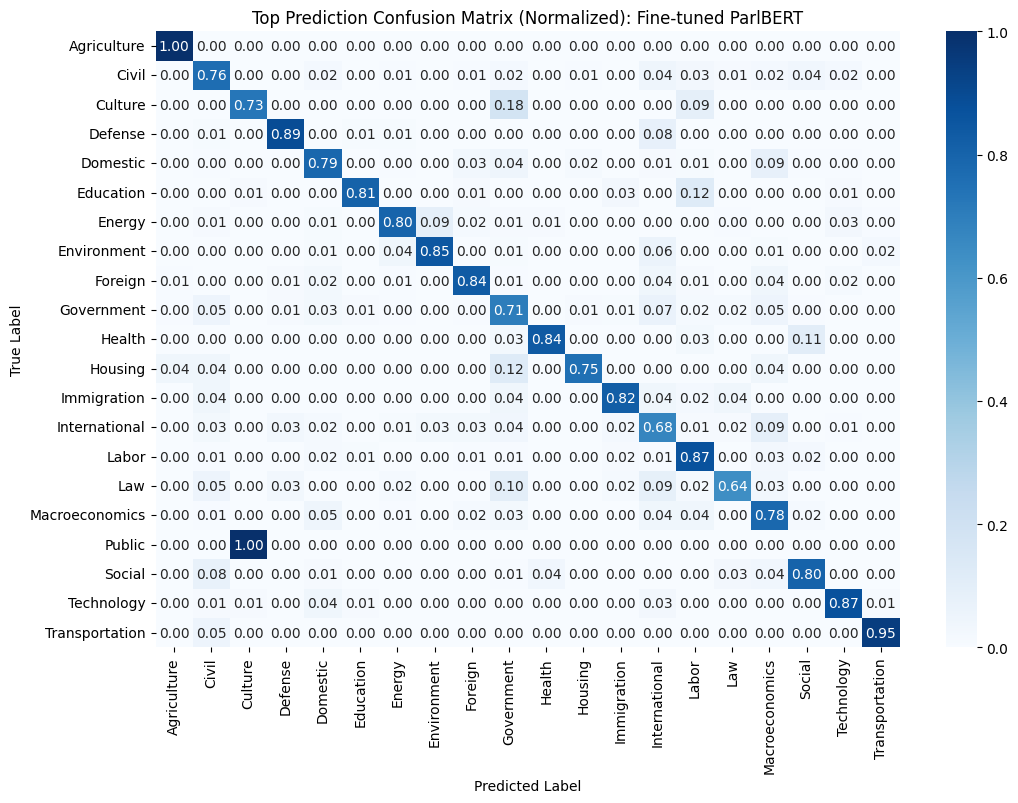

In [ ]:
confusion_top = pd.crosstab(
    test_labels_named,
    pred_labels_named,
    rownames=['True Label'],
    colnames=['Predicted Label'],
    normalize='index'
)

plt.figure(figsize=(12,8))
sns.heatmap(confusion_top, annot=True, fmt=".2f", cmap="Blues")
plt.title("Top Prediction Confusion Matrix (Normalized): Fine-tuned ParlBERT")
plt.show()

# Train BERT model for further usage

In [30]:
from torch.utils.data import ConcatDataset

best_num_context = 2
train_encodings = tokenize_with_context_segment_ids(
    texts_balanced_final,
    tokenizer=tokenizer,
    num_context=best_num_context,
    max_length=256
)

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "token_type_ids": train_encodings["token_type_ids"],
    "labels": torch.tensor(labels_balanced_final)
})

test_encodings = tokenize_with_context_segment_ids(
    test_texts,
    tokenizer=tokenizer,
    num_context=best_num_context,
    max_length=256
)

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "token_type_ids": test_encodings["token_type_ids"],
    "labels": torch.tensor(test_labels)
})

full_dataset = ConcatDataset([train_dataset, test_dataset])

In [31]:
# get updated class weights (since we do not use the test set for testing anymore)
all_labels = np.concatenate([labels_balanced_final, test_labels])
class_counts = np.bincount(all_labels)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float)


In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    parlbert,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

In [34]:
training_args = TrainingArguments(
    output_dir="./results_final",
    save_strategy="epoch",
    learning_rate=2.672669365772627e-05,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.014810009452270324,
)

In [37]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=full_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

/tmp/ipython-input-3592999002.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


In [38]:
trainer.train()
trainer.save_model("./final_finetuned_parlBERT")
tokenizer.save_pretrained("./final_finetuned_parlBERT")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hannahsteinbach (witcrafts) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,1.376400
1000,0.986600
1500,0.876300
2000,0.838800
2500,0.763600
3000,0.484800
3500,0.410100
4000,0.417700
4500,0.431900
5000,0.402800


('./final_finetuned_parlBERT/tokenizer_config.json',
 './final_finetuned_parlBERT/special_tokens_map.json',
 './final_finetuned_parlBERT/vocab.txt',
 './final_finetuned_parlBERT/added_tokens.json',
 './final_finetuned_parlBERT/tokenizer.json')